# 기계학습 실습 7: Dense Neural Network로 MNIST 분류

## 학습 목표
- 28x28 MNIST 이미지를 784차원 벡터로 펼쳐 Dense Neural Network에 입력한다.
- hidden layer, activation, dropout, softmax output의 역할을 이해한다.
- 학습 곡선, test accuracy, 오분류 이미지를 확인한다.

## 사용할 데이터
- `tf.keras.datasets.mnist`: 28x28 손글씨 숫자 이미지

## 직접 바꿔볼 것
- hidden layer의 neuron 수
- activation function
- dropout rate
- epoch 수


In [2]:
from __future__ import absolute_import, division, print_function, unicode_literals
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

#### Load and prepare the [MNIST dataset](http://yann.lecun.com/exdb/mnist/) and Convert the samples from integers to floating-point numbers:

<img src="https://drive.google.com/uc?export=view&id=1oKGKJawQMry5LoLKNNyLQZYcx82VQtro" align="center" width="600"/>
<div>
<div>
<img src="attachment:train_test.jpg" width="500"/>
</div>


In [3]:
mnist = tf.keras.datasets.mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0        ## 정수형 데이터를 실수형으로 바꿔줌

#### 불러온 데이터를 확인해 본다.

In [4]:
x_train.shape

(60000, 28, 28)

In [5]:
set(y_train)

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9}

In [6]:
x_test.shape

(10000, 28, 28)

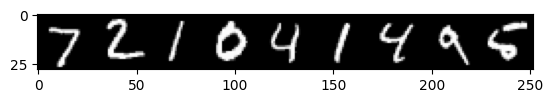

In [7]:
images = x_test[0,:,:]
for i in range(8):
    images = np.concatenate((images, x_test[i+1,:,:]), axis=1)
plt.gray()
plt.imshow(images)
plt.show()

In [8]:
y_test[:9]

array([7, 2, 1, 0, 4, 1, 4, 9, 5], dtype=uint8)

#### Build the `tf.keras.Sequential` model by stacking layers. Choose an optimizer and loss function for training:
https://keras.io/ko/models/model/

## 모형 생성

#### 인공신경망 (ANN) 모형

<div style="display:flex; gap:24px; align-items:flex-start;">
  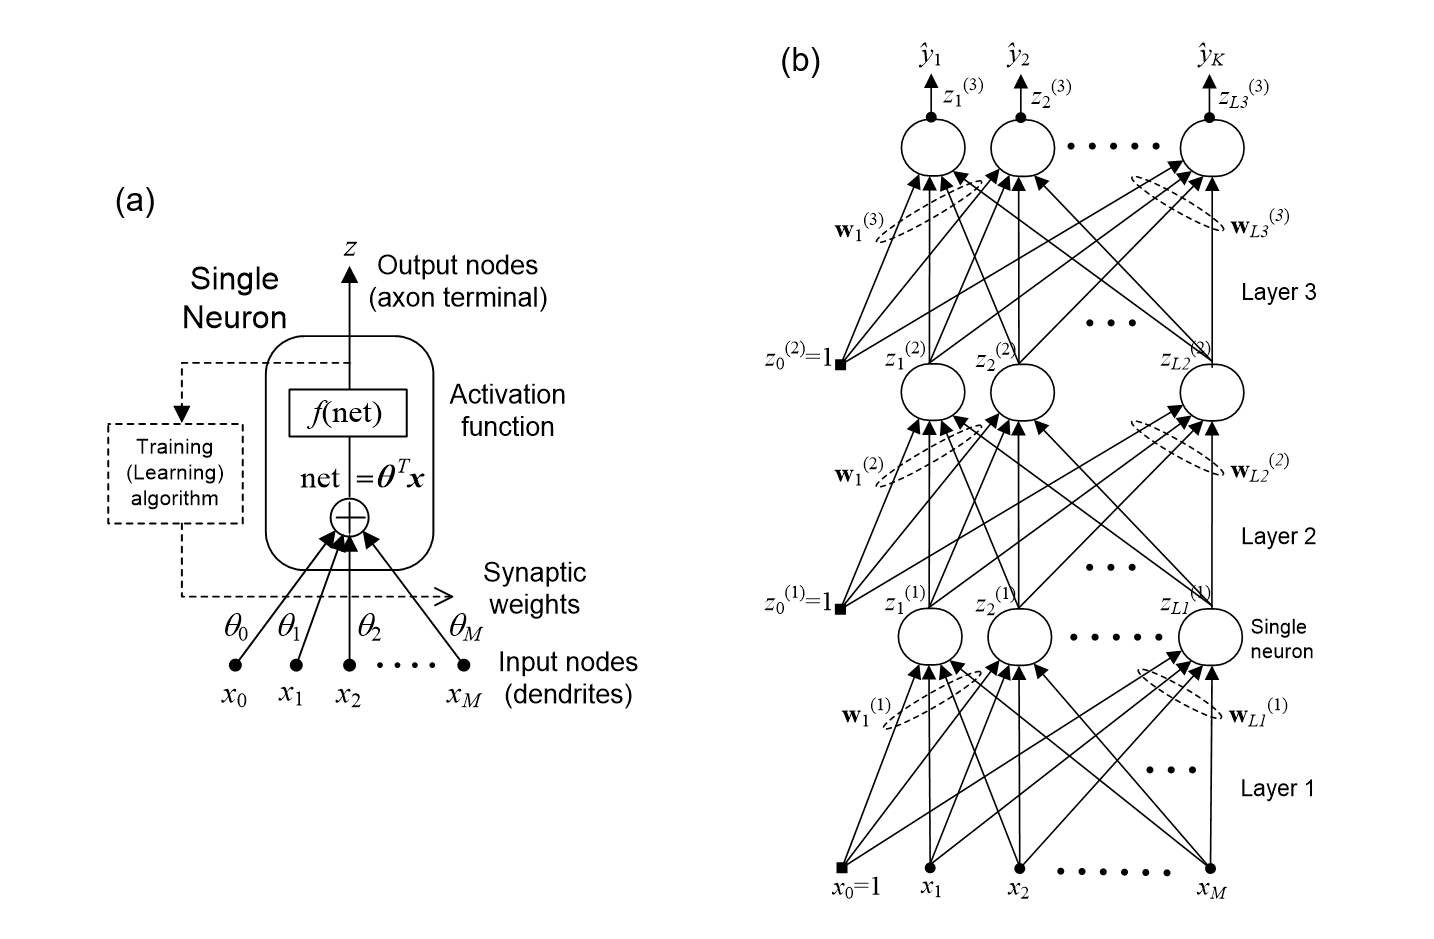  
</div>


## Model:

### Binary ANN with sigmoid output

#### Hidden layer
$$
{\bf h}_1 = ReLU({\bf W}_1^T {\bf x} + {\bf b}_1)
$$

#### Output layer
$$
\hat{p}_1 = \sigma ({\bf w}_2^T {\bf h}_1 + b_2) = Pr\{Cancer \mid {\bf x}\}
$$

#### Cost to minimize
$$
-\frac{1}{n}\sum_i \left[y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)\right]
$$

출력값 `0.5`를 기준으로 `Cancer` 여부를 판정할 수 있지만, 실제 진단 문제에서는 threshold를 바꾸며 sensitivity와 specificity의 trade-off를 함께 확인해야 합니다.


In [ ]:
model = tf.keras.models.Sequential([
  tf.keras.layers.Flatten(input_shape=(28, 28)),   ## Convert 2D (28x28) data to 1D (28*28 = 784)
  tf.keras.layers.Dense(15, activation='sigmoid'),   ## # of neurons in the first layer = 128 --> First layer weight matrix size = 784 by 128
  tf.keras.layers.Dropout(0.5),
  tf.keras.layers.Dense(40, activation='relu'),   ## # of neurons in the first layer = 128 --> First layer weight matrix size = 784 by 128
  tf.keras.layers.Dropout(0.5),
  tf.keras.layers.Dense(10, activation='softmax')  ## # of neurons in the second layer = 10 = # of classes
])

model.compile(optimizer= tf.keras.optimizers.Adam(learning_rate=0.001), #'adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

/home/syoon/Programs/anaconda3/envs/py312/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
E0000 00:00:1782035022.360574 2031390 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1782035022.361028 2032187 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1782035022.405297 2031390 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guid

#### Dropout

<div style="display:flex; gap:24px; align-items:flex-start;">
  <img src="data:image/png;base64, ..." width="500"/>  
</div>


- Keras 손실함수: https://keras.io/api/losses/
- Keras 손실함수 (간략한 설명): https://cheris8.github.io/artificial%20intelligence/DL-Keras-Loss-Function/

In [10]:
(784+1)*15, (15+1)*40, 10*40

(11775, 640, 400)

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │        11,775 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 40)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           410 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,825 (50.10 KB)

 Trainable params: 12,825 (50.10 KB)

 Non-trainable params: 0 (0.00 B)

#### Train and evaluate the model:

In [12]:
history = model.fit(x_train, y_train, batch_size = 100, epochs=12,
                    validation_data=(x_test, y_test))

Epoch 1/12
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4017 - loss: 1.6726 - val_accuracy: 0.8525 - val_loss: 0.7833
Epoch 2/12
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6032 - loss: 1.1584 - val_accuracy: 0.8909 - val_loss: 0.5677
Epoch 3/12
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6450 - loss: 1.0574 - val_accuracy: 0.8989 - val_loss: 0.5117
Epoch 4/12
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6729 - loss: 0.9997 - val_accuracy: 0.9001 - val_loss: 0.4732
Epoch 5/12
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6787 - loss: 0.9734 - val_accuracy: 0.8995 - val_loss: 0.4637
Epoch 6/12
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6925 - loss: 0.9424 - val_accuracy: 0.9034 - val_loss: 0.4445
Epoch 7/12
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6968 - loss: 0.9302 - val_accuracy: 0.9025 - val_loss: 0.4446
Epoch 8/12
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7000 - loss: 0.9205 - val_accuracy: 0.

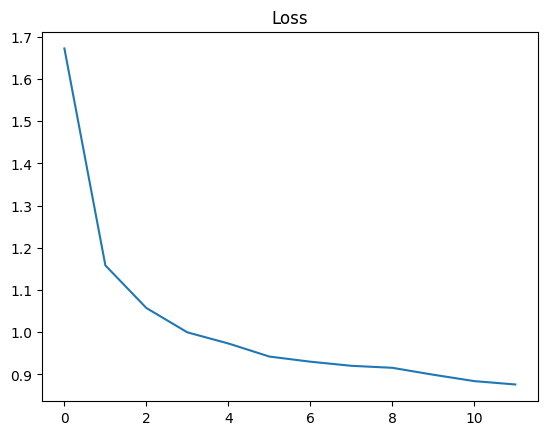

In [13]:
plt.plot(history.history["loss"])
plt.title("Loss")
plt.show()

In [14]:
perf_test = model.evaluate(x_test, y_test)
perf_train = model.evaluate(x_train, y_train)

print(model.metrics_names)
print(np.round(perf_test,4))
print(np.round(perf_train,4))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9082 - loss: 0.4078
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9096 - loss: 0.3914
['loss', 'compile_metrics']
[0.4078 0.9082]
[0.3914 0.9096]


####  The image classifier is now trained to ~98% accuracy on this dataset. To learn more, read the [TensorFlow tutorials](https://www.tensorflow.org/beta/tutorials/).

#### 학습된 모델을 이용하여 몇개 테스트 샘플에 대해 분류 수행

In [15]:
metric = model.predict( x_test)
print(metric.shape)

y_pred = np.argmax(metric, axis=1)
print(y_pred[:30])
print(y_test[:30])

# y_pred2 = model.predict_classes( x_test)
# print(y_pred2[:30])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
(10000, 10)
[7 2 1 0 4 1 4 9 6 9 0 6 9 0 1 5 9 7 8 4 9 6 4 5 4 0 7 4 0 1]
[7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4 9 6 6 5 4 0 7 4 0 1]


In [16]:
metric[1,:].round(6)

array([0.00000e+00, 9.75400e-03, 9.69781e-01, 1.78270e-02, 0.00000e+00,
       5.80000e-05, 2.82000e-04, 2.16400e-03, 1.34000e-04, 0.00000e+00],
      dtype=float32)

In [17]:
np.sum(y_test != y_pred)

918

In [18]:
metric[0,:]

array([7.8258608e-11, 6.6188604e-06, 9.7821862e-07, 2.7329766e-04,
       9.7882992e-07, 1.6169241e-05, 1.3074484e-15, 9.8579991e-01,
       3.1721148e-09, 1.3901959e-02], dtype=float32)

#### 분류(예측) 결과 확인

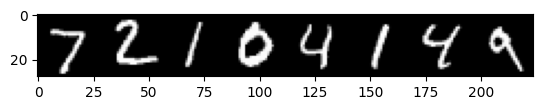

Predicted labels:  [7 2 1 0 4 1 4 9]


In [19]:
images = x_test[0,:,:]
for i in range(7):
    images = np.concatenate((images, x_test[i+1,:,:]), axis=1)
plt.gray()
plt.imshow(images)
plt.show()
print('Predicted labels: ', y_pred[:8])

#### 분류(예측) 오류 예

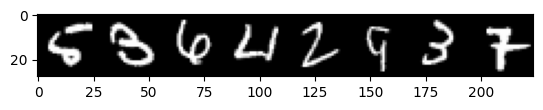

Predicted labels:  [6 8 4 6 3 4 2 9]
Original labels:   [5 3 6 4 2 9 3 7]


In [20]:
b = y_test != y_pred
y_t_error = y_test[b]
y_p_error = y_pred[b]
x_t_error = x_test[b,:,:]

images = x_t_error[0,:,:]
for i in range(7):
    images = np.concatenate((images, x_t_error[i+1,:,:]), axis=1)
plt.gray()
plt.imshow(images)
plt.show()
print('Predicted labels: ', y_p_error[:8])
print('Original labels:  ', y_t_error[:8])

In [21]:
len(y_pred)

10000

#### 학습된 모델을 나중에 사용하려면 저장해둬야 ...

In [22]:
model.save('My_first_model.h5')

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │        11,775 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 40)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           410 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,477 (150.30 KB)

 Trainable params: 12,825 (50.10 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 25,652 (100.21 KB)

In [24]:
loaded_model = tf.keras.models.load_model('My_first_model.h5')


In [25]:
loaded_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │        11,775 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 40)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 40)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           410 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,827 (50.11 KB)

 Trainable params: 12,825 (50.10 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [26]:
metric = loaded_model.predict( x_test)
print(metric.shape)

y_pred = np.argmax(metric, axis=1)
print(y_pred[:30])


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
(10000, 10)
[7 2 1 0 4 1 4 9 6 9 0 6 9 0 1 5 9 7 8 4 9 6 4 5 4 0 7 4 0 1]
